<a href="https://colab.research.google.com/github/giveyourselfaTRY/phototaxis-pomdp-crn/blob/main/02_Data_driven_IRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing

In [1]:
from pathlib import Path
import sys, subprocess, os

REPO_NAME = "phototaxis-pomdp-crn"
REPO_URL = "https://github.com/giveyourselfaTRY/phototaxis-pomdp-crn.git"

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path(f"/content/{REPO_NAME}")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    os.chdir(ROOT)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name != REPO_NAME and (ROOT / REPO_NAME).exists():
        ROOT = ROOT / REPO_NAME

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
CKPT_DIR = ROOT / "checkpoints"
OUT_DIR = ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
TRAJ_DIR = OUT_DIR / "trajectories"
TAB_DIR = OUT_DIR / "tables"

for d in [RAW_DIR, PROC_DIR, CKPT_DIR, FIG_DIR, TRAJ_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("RAW_DIR =", RAW_DIR)
print("PROC_DIR =", PROC_DIR)
print("CKPT_DIR =", CKPT_DIR)

ROOT = /content/phototaxis-pomdp-crn
RAW_DIR = /content/phototaxis-pomdp-crn/data/raw
PROC_DIR = /content/phototaxis-pomdp-crn/data/processed
CKPT_DIR = /content/phototaxis-pomdp-crn/checkpoints


In [2]:
import numpy as np, pandas as pd, io, os

FPS = 7.2
CSV = RAW_DIR / "tr_1634_52.csv"
DTI = RAW_DIR / "dti.npy"
IMG_DEFAULT = RAW_DIR / "test.jpeg"

if not CSV.exists():
    raise FileNotFoundError(f"Missing raw csv: {CSV}")
if not DTI.exists():
    raise FileNotFoundError(f"Missing dti file: {DTI}")

# read CSV
def read_movie52_space_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln for ln in f.readlines() if not ln.strip().startswith("#")]
    df = pd.read_csv(io.StringIO("".join(lines)), delim_whitespace=True, header=None,
                     names=["frame","x","y","cell_id"])
    df = df.astype({"frame": float, "x": float, "y": float, "cell_id": float})
    df["cell_id"] = df["cell_id"].astype(int)
    return df

def inspect_frames_and_dti(df, dti=None):
    gmin, gmax = int(df["frame"].min()), int(df["frame"].max())
    nunq = int(df["frame"].nunique())
    print(f"[GLOBAL] frame_min={gmin}, frame_max={gmax}, unique_frames={nunq}")

    if dti is not None:
        dti = np.asarray(dti, float)
        print(f"[DTI] len={len(dti)}  mean={dti.mean():.5f}  std={dti.std():.5f}  "
              f"min={dti.min():.5f}  max={dti.max():.5f}")
        uniform_dt = 1.0/FPS
        dev = np.abs(dti - uniform_dt)
        print(f"[DTI] median|dti-1/fps|={np.median(dev):.5f}  p95={np.percentile(dev,95):.5f}  "
              f"CV={dti.std()/(dti.mean()+1e-12):.4f}")
        exp_len = gmax - gmin
        print(f"[CONSISTENCY] expected_len≈frame_range={exp_len}  match? {abs(len(dti)-exp_len)<=1}")

    rows=[]
    for cid, g in df.sort_values(["cell_id","frame"]).groupby("cell_id"):
        fmin, fmax = int(g["frame"].min()), int(g["frame"].max())
        n = len(g)
        nunq = g["frame"].nunique()
        rows.append(dict(cell_id=int(cid), frames=n, unique_frames=int(nunq),
                         frame_min=fmin, frame_max=fmax))
    info = pd.DataFrame(rows).sort_values("cell_id")
    print("\n[PER-CELL] head():")
    display(info.head())
    print(f"[PER-CELL] cells={len(info)}, number of frames per cell: mean={info['frames'].mean():.1f}, "
          f"min={info['frames'].min()}, max={info['frames'].max()}")
    print(f"[PER-CELL] unique frames per cell: mean={info['unique_frames'].mean():.1f}, "
          f"min={info['unique_frames'].min()}, max={info['unique_frames'].max()}")
    return info

In [3]:
# df  = read_movie52_space_csv(CSV)
# dti = np.load(DTI, allow_pickle=True).astype(float)
# inspect_frames_and_dti(df, dti)



---

## Mapping DTI to frame-level time intervals

Let the movie frames span integers $(f\in{f_{\min},\ldots,f_{\max}}).$
The DTI file provides **inter-frame intervals** $(\Delta t_k)$ for $(k=0,\ldots, L-1),$ where
$$
L = f_{\max}-f_{\min},\qquad
\Delta t_k \text{ corresponds to } (f_{\min}+k)\to(f_{\min}+k+1).
$$
We build a **global absolute time axis** by cumulative sum:
$$
T(0)=0,\qquad
T(k)=\sum_{j=0}^{k-1}\Delta t_j\quad (k\ge1).
$$
For any frame $(f)$, the absolute time is looked up by
$$
t_{\text{abs}}(f)=T\big(f-f_{\min}\big).
$$

> This automatically handles **missing frames**: if a trajectory jumps from $f_0$ to $f_{I}>f_0+1$, then
> $(t_{\text{abs}}(f_{I})-t_{\text{abs}}(f_0)=\sum_{k=f_0}^{f_{I}-1}\Delta t_k).$

In code (`_build_time_lookup_from_dti`), `cum_t = [0, cumsum(DTI)]` implements $T(\cdot)$.

## Per-trajectory preprocessing( time, velocity and heading )

For a trajectory $c$, let its ordered frames be $\{f_i^c\}_{i=0}^{n_c-1}$ with positions $(x_i^c,y_i^c)$.

* **Relative time** (per trajectory):
  $$
  t_i^c = t_{\text{abs}}(f_i^c);-;t_{\text{abs}}(f_0^c).
  $$
* **Time step**:
  $$
  \Delta t_i^c =
  \begin{cases}
  0, & i=0,\
  t_{\text{abs}}(f_i^c)-t_{\text{abs}}(f_{i-1}^c), & i\ge1.
  \end{cases}
  $$
* **Displacements**:
  $$
  \Delta x_i^c = x_i^c - x_{i-1}^c,\qquad
  \Delta y_i^c = y_i^c - y_{i-1}^c\quad (i\ge1).
  $$
* **Velocities** (defined on row (i), using the interval ([t_{i-1},t_i))):
  $$
  v_{x,i}^c = \frac{\Delta x_i^c}{\Delta t_i^c},\qquad
  v_{y,i}^c = \frac{\Delta y_i^c}{\Delta t_i^c},\qquad
  |v_i^c|=\sqrt{(v_{x,i}^c)^2+(v_{y,i}^c)^2}.
  $$
* **Heading angle** and **wrapped angular speed**:
  $$
  \theta_i^c=\operatorname{atan2}(\Delta y_i^c,\Delta x_i^c),\qquad
  \omega_i^c=\frac{\operatorname{wrap}(\theta_i^c-\theta_{i-1}^c)}{\Delta t_i^c}\quad (i\ge2),
  $$
  where $\operatorname{wrap}(\alpha)=(\alpha+\pi)\bmod 2\pi-\pi$ enforces $(-\pi,\pi]$.

In [5]:
import numpy as np, pandas as pd, io, os

# --- build global time table using DTI ：frame f -> t_abs_sec ---
def _build_time_lookup_from_dti(dti, frame_min_global: int):
    dti = np.asarray(dti, float)
    cum_t = np.concatenate([[0.0], np.cumsum(dti)])        # len = len(dti)+1
    def t_of_frame(f):
        idx = int(round(f - frame_min_global))             # f 可以是浮点，先对齐到整数索引
        idx = max(0, min(idx, len(cum_t)-1))
        return cum_t[idx]
    return t_of_frame

# --- align the DTI time stamps with the frames--
def attach_time_and_velocity_from_dti(df, dti_path=None, fps=None, pixel_to_um=None):
    df = df.sort_values(["cell_id","frame"]).copy()

    # prioritize with dti
    gmin = int(df["frame"].min())
    if dti_path and os.path.exists(dti_path):
        dti = np.load(dti_path, allow_pickle=True).astype(float)
        t_lookup = _build_time_lookup_from_dti(dti, frame_min_global=gmin)
        df["t_abs_sec"] = df["frame"].apply(lambda f: t_lookup(f))
    else:
        assert fps is not None, "need either dti_path or fps"
        df["t_abs_sec"] = df["frame"] / float(fps)

    # 2) t&dt
    df["t_sec"]   = df.groupby("cell_id")["t_abs_sec"].transform(lambda s: s - s.iloc[0])
    df["dt_sec"]  = df.groupby("cell_id")["t_abs_sec"].diff().fillna(0.0)

    # 3) velocity
    df["dx"] = df.groupby("cell_id")["x"].diff()
    df["dy"] = df.groupby("cell_id")["y"].diff()
    eps = 1e-12
    dt = df["dt_sec"].to_numpy().copy()
    dt[dt < eps] = np.nan
    df["vx"] = df["dx"] / dt
    df["vy"] = df["dy"] / dt
    df["v_speed"] = np.sqrt(df["vx"]**2 + df["vy"]**2)
    if pixel_to_um is not None:
        for c in ["vx","vy","v_speed"]:
            df[c] *= float(pixel_to_um)

    # 4) heading direction & angular speed
    df["heading_rad"] = np.arctan2(df["dy"], df["dx"])
    wrap = lambda a: (a + np.pi) % (2*np.pi) - np.pi
    dth = df.groupby("cell_id")["heading_rad"].diff()
    df["ang_vel_rad_s"] = wrap(dth) / df["dt_sec"]


    return df


In [6]:
# @title Clean pipeline for movie 52
raw = read_movie52_space_csv(CSV)
print("Raw shape:", raw.shape)

df = attach_time_and_velocity_from_dti(raw, dti_path=DTI, fps=FPS)
print("Cleaned shape:", df.shape)

# clean: drop first step if dt<=0
clean = df[(df["dt_sec"] >= 0)].copy().reset_index(drop=True)

OUT = PROC_DIR / "clean_movie_52_with_speed.csv"
clean.to_csv(OUT, index=False)

print("Saved:", OUT, "rows:", len(clean))
clean.head()

Raw shape: (17603, 4)
Cleaned shape: (17603, 14)
Saved: /content/phototaxis-pomdp-crn/data/processed/clean_movie_52_with_speed.csv rows: 17603


/tmp/ipykernel_26619/2068890000.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(io.StringIO("".join(lines)), delim_whitespace=True, header=None,


,frame,x,y,cell_id,t_abs_sec,t_sec,dt_sec,dx,dy,vx,vy,v_speed,heading_rad,ang_vel_rad_s
0,64.0,677.612638,1187.600217,0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,65.0,679.265230,1178.830878,0,0.13,0.13,0.13,1.652592,-8.769339,12.712248,-67.456455,68.643824,-1.384530,NaN
2,66.0,683.688730,1170.357778,0,0.26,0.26,0.13,4.423500,-8.473100,34.026921,-65.177692,73.525254,-1.089654,2.268276
3,67.0,687.980679,1164.028699,0,0.39,0.39,0.13,4.291949,-6.329079,33.014990,-48.685222,58.823808,-0.974898,0.882734
4,68.0,694.142970,1150.810408,0,0.46,0.46,0.07,6.162291,-13.218291,88.032731,-188.832726,208.344811,-1.134557,-2.280840


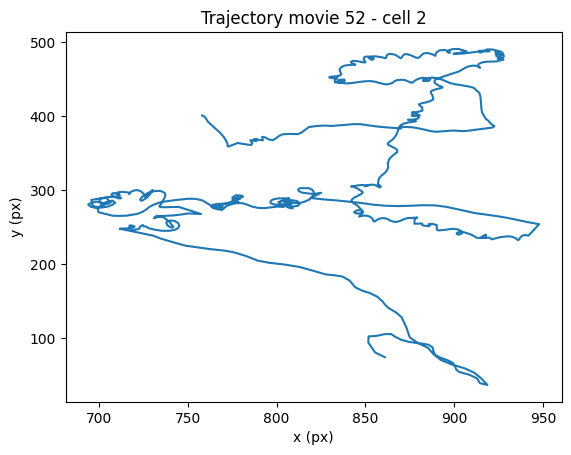

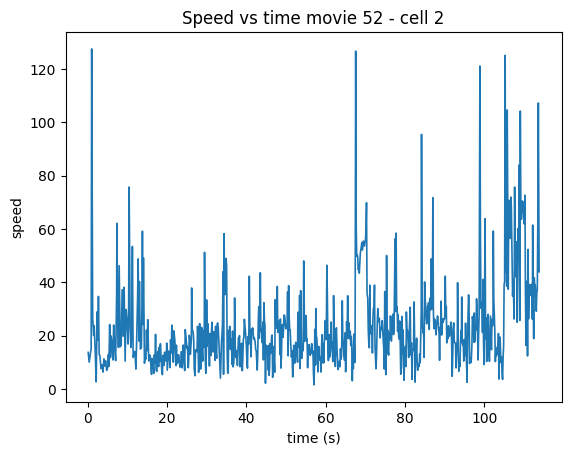

In [8]:
# @title Pick longest track & visualize trajectory / speed
import matplotlib.pyplot as plt

def pick_longest_track(df):
    counts = df.groupby("cell_id")["frame"].count().sort_values(ascending=False)
    return int(counts.index[0])

def plot_track(df, cid, title=""):
    sub = df[df["cell_id"]==cid].copy()
    sub = sub[sub["dt_sec"]>0]
    if sub.empty:
        print("Empty track.")
        return
    plt.figure()
    plt.plot(sub["x"].values, sub["y"].values, linewidth=1.5)
    # plt.gca().invert_yaxis()
    plt.xlabel("x (px)")
    plt.ylabel("y (px)")
    plt.title(f"Trajectory {title} - cell {cid}")
    plt.show()

    plt.figure()
    plt.plot(sub["t_sec"].values, sub["v_speed"].values, linewidth=1.2)
    plt.xlabel("time (s)")
    plt.ylabel("speed")
    plt.title(f"Speed vs time {title} - cell {cid}")
    plt.show()
df52p = pd.read_csv(PROC_DIR / "clean_movie_52_with_speed.csv")
cid52 = pick_longest_track(df52p)

plot_track(df52p, cid52, "movie 52")



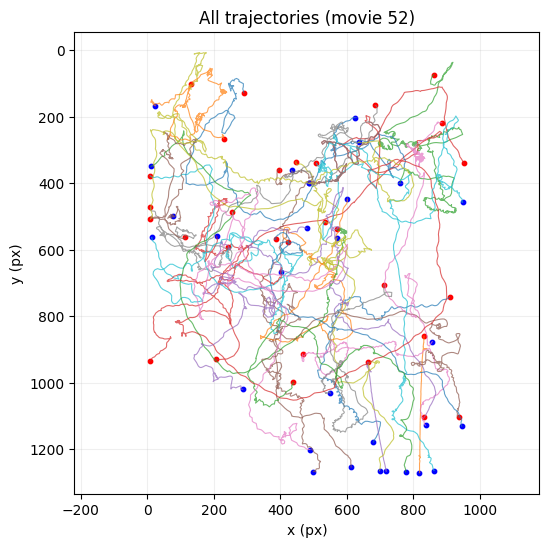

In [9]:
import numpy as np
import pandas as pd


df = pd.read_csv(PROC_DIR / "clean_movie_52_with_speed.csv")

plt.figure(figsize=(6,6))
for cid, g in df.sort_values(["cell_id","t_sec"]).groupby("cell_id"):
    g = g[g["dt_sec"]>0]
    if len(g) == 0:
        continue
    plt.plot(g["x"].values, g["y"].values, lw=0.8, alpha=0.7)
    x0,y0=float(g["x"].values[0]),float(g["y"].values[0])
    x1,y1=float(g["x"].values[-1]),float(g["y"].values[-1])
    plt.scatter([x0],[y0],c='b',s=10,label='start')
    plt.scatter([x1],[y1],c='r',s=10,label='end')

plt.gca().invert_yaxis()
plt.axis('equal')
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.title("All trajectories (movie 52)")
plt.grid(alpha=0.2)
plt.show()

We can get the position of the light source directly from the capture

In [10]:
import imageio.v2 as imageio

def detect_light_center_numpy(img_path, percentile=99.5, use_weight=True):

    img = imageio.imread(img_path)  # (H,W,[C])
    if img.ndim == 3:
        gray = img.mean(axis=2).astype(float)
    else:
        gray = img.astype(float)
    H, W = gray.shape

    thr = np.percentile(gray, percentile)   # highlight threshold
    mask = gray >= thr                      # light area
    if mask.sum() == 0:
        raise ValueError("highlight area not detected")

    ys, xs = np.nonzero(mask)
    if use_weight:
        w = gray[mask]                      # weighted with lighted area
        cx = float((xs * w).sum() / w.sum())
        cy = float((ys * w).sum() / w.sum())
    else:
        cx = float(xs.mean()); cy = float(ys.mean())
    return (cx, cy), gray, mask


In [11]:
def plot_all_trajectories_with_light(df, light_xy, img_path=None,
                                     show_image=False, invert_y=True):

    cx, cy = light_xy
    plt.figure(figsize=(6,6))

    if img_path and show_image:
        import imageio.v2 as imageio
        img = imageio.imread(img_path)
        plt.imshow(img)
    # draw trajectory
    for cid, g in df.groupby("cell_id"):
        g = g[g["dt_sec"]>0]
        if len(g)==0: continue
        plt.plot(g["x"].values, g["y"].values, lw=0.7, alpha=0.8)
        x0,y0=float(g["x"].values[0]),float(g["y"].values[0])
        x1,y1=float(g["x"].values[-1]),float(g["y"].values[-1])
        plt.scatter([x0],[y0],c='b',s=10)
        plt.scatter([x1],[y1],c='r',s=10)
    # light source center
    plt.scatter([cx],[cy], marker='*', s=220, c='red', label='light center')

    if invert_y: plt.gca().invert_yaxis()   # invert y axis
    plt.axis('equal'); plt.grid(alpha=0.2)
    plt.xlabel("x (px)"); plt.ylabel("y (px)")
    plt.title("All trajectories with light center")
    plt.legend(loc="best")
    plt.show()


light center (px): (252.10614313608545, 335.41309535888786)


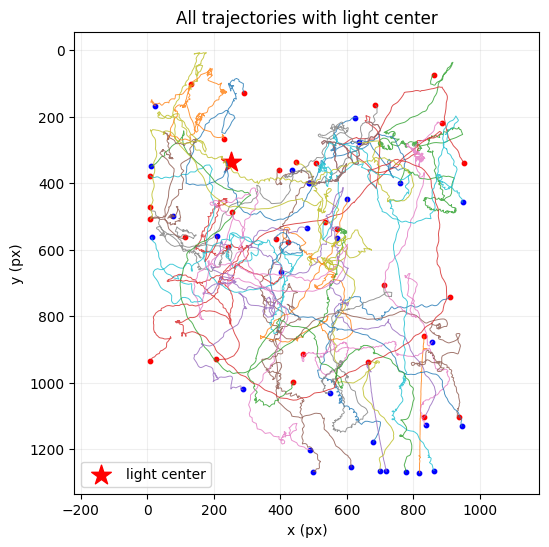

In [12]:
IMG = IMG_DEFAULT

if not IMG.exists():
    raise FileNotFoundError(f"Missing light image: {IMG}")

(light_xy, gray, mask) = detect_light_center_numpy(IMG, percentile=99.5)
print("light center (px):", light_xy)

# put the light center on the plot of all trajectories
plot_all_trajectories_with_light(df, light_xy, img_path=IMG, show_image=False)



## 3) Forward-aligned interval features

For each trajectory, row $i$ represents a frame $f_i$, while action applies on the **interval**
$$
\mathcal{I}_i = [t_i,,t_{i+1})\quad (i=0,\ldots,n_c-2).
$$
We therefore **forward-align** the interval features to the next row:
$$
v^{\mathrm{fwd}}_i \equiv |v_{i+1}|,\qquad
\omega^{\mathrm{fwd}}_i \equiv \omega_{i+1}.
$$

and we **write the label of interval (\mathcal{I}_i) into row (i+1)**:

* first row has no label (there is no preceding interval),
* the last row receives the label of the last interval.



## 4) run / tumble labeling rule

We assign a discrete action $a_i\in\{0=\mathrm{run},1=\mathrm{tumble}\}$ to each interval $\mathcal{I}_i$ using two thresholds:

1. **Low-speed threshold** (global robust estimate from all intervals):
   $$
   \varepsilon_v = \operatorname{Quantile}_q\big({v^{\mathrm{fwd}}_i}\big),\quad q\in[0,1]\ \text{(e.g. }q=0.05\text{)}.
   $$

2. **High-turn threshold** from a **2-means** clustering on $|\omega^{\mathrm{fwd}}|$:
   Fit KMeans with $K=2$ to $\{|\omega^{\mathrm{fwd}}_i|\}$, obtain centers
   $\mu_{\text{lo}}\le\mu_{\text{hi}}$, and set
   $$
   \tau_\omega = \frac{\mu_{\text{lo}}+\mu_{\text{hi}}}{2}.
   $$
   <!-- (Fallback when samples are scarce: $\tau_\omega = 3\cdot\operatorname{median}(|\omega^{\mathrm{fwd}}|)+\epsilon$.) -->

**Decision rule (per interval $\mathcal{I}_i$)**:
$$
a_i=
\begin{cases}
1 & \text{if } v^{\mathrm{fwd}}_i  \le \varepsilon_v \wedge |\omega^{\mathrm{fwd}}_i|>\tau_\omega \quad\text{(near-stationary & large turn)},
\\
0 & \text{otherwise (run)}.
\end{cases}
$$

If $\omega^{\mathrm{fwd}}_i$ is invalid (NaN/inf), we fall back to the speed criterion:
$$
a_i = \mathbb{1}\{v^{\mathrm{fwd}}_i\le\varepsilon_v\}.
$$

Finally we **write action** $a_i$ to row $i+1$:
$$
\text{row }(i+1).\text{action_id} = a_i,\qquad
\text{row }0.\text{action_id}=\mathrm{NaN}.
$$
We also map `action_id → {'run','tumble'}`.

---



* DTI gives **movie-level** intervals between consecutive global frames; building $t_{\text{abs}}(f)$ ensures that every trajectory—no matter where it starts or how many frames it skips—uses the **true elapsed time** between its samples.
* Velocities and angular speeds are computed on exact $\Delta t$, so the interval features $(v^{\mathrm{fwd}},\omega^{\mathrm{fwd}})$ are faithful descriptors of $[t_i,t_{i+1})$.
* Forward-aligned labeling avoids the “action on first row” ambiguity and makes the table consistent with the POMDP step semantics.

---
<!--
### Pseudocode (what your code already does)

1. Read CSV → sort by `(cell_id, frame)`.
2. Build `t_abs_sec = T(frame - f_min)` from DTI; per cell set `t_sec = t_abs - t_abs[first]`, `dt_sec = diff(t_abs)`.
3. Compute `dx,dy → vx,vy,v_speed`; `heading = atan2(dy,dx)`; `ang_vel = wrap(diff(heading))/dt_sec`.
4. Forward features: `v_fwd=v_speed.shift(-1)`, `w_fwd=ang_vel.shift(-1)`.
5. Compute thresholds:
   (\varepsilon_v = \mathrm{Quantile}*q(v^{\mathrm{fwd}})),
   (\tau*\omega = \tfrac{1}{2}(\mu_{\text{lo}}+\mu_{\text{hi}})) from KMeans on (|\omega^{\mathrm{fwd}}|).
6. For each cell, create interval labels (a_i) by the rule above and write them to row (i+1).
   First row stays NaN; last row has a label.
   Add `action_id ∈ {0,1}` and `action ∈ {'run','tumble'}`. -->




### add actions to the data

In [13]:
import numpy as np, pandas as pd
from sklearn.cluster import KMeans

def assign_actions_next_row(df: pd.DataFrame, speed_q=0.05, min_dwell_frames=0, return_str=True):
    """
    Rules:
      - tumble ⇐ (low speed) AND (high angular speed)
      - when angular speed invalid，only determine with low speed


    input:
      cell_id, t_sec, v_speed, ang_vel_rad_s
    output:
      action_id ∈ {0,1}, and choose action ∈ {'run','tumble'}
    """
    need = {"cell_id", "t_sec", "v_speed", "ang_vel_rad_s"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"df miss column: {missing}")

    out = df.sort_values(["cell_id","t_sec"]).copy()

    # forward-alignment: write [t_i -> t_{i+1})features into row i+1
    out["v_fwd"] = out.groupby("cell_id")["v_speed"].shift(-1)
    out["w_fwd"] = out.groupby("cell_id")["ang_vel_rad_s"].shift(-1)

    # ========= global threshold =========
    v_all = out["v_fwd"].replace([np.inf,-np.inf], np.nan).dropna().to_numpy()
    w_all = out["w_fwd"].replace([np.inf,-np.inf], np.nan).dropna().to_numpy()

    # quantile for low-speed
    eps_v = float(max(1e-6, np.nanquantile(v_all, speed_q) if v_all.size else 1e-3))

    #threshold for angular speed （KMeans ）
    km = KMeans(n_clusters=2, n_init=10, random_state=0)
    labels = km.fit_predict(np.abs(w_all).reshape(-1,1)) if w_all.size else np.array([0,1])
    centers = np.sort(km.cluster_centers_.ravel()) if w_all.size else np.array([0.0, 1.0])
    tau_omega = float((centers[0] + centers[1]) / 2.0)

    # ========= labeling =========
    out["action_id"] = pd.Series(np.nan, index=out.index, dtype=pd.Int64Dtype())

    def _merge_short_segments(arr, min_len):

        if min_len <= 1:
            return arr
        arr2 = arr.copy()
        i = 0
        L = len(arr2)
        while i < L:
            j = i
            while j < L and arr2[j] == arr2[i]:
                j += 1
            seg_len = j - i
            if seg_len < min_len:
                left  = arr2[i-1] if i-1 >= 0 else arr2[j] if j < L else arr2[i]
                right = arr2[j]   if j   < L else left
                fill  = left if left == right else right
                arr2[i:j] = fill
            i = j
        return arr2

    for cid, g in out.groupby("cell_id"):
        idx = g.index.to_numpy()
        v   = g["v_fwd"].to_numpy()
        w   = g["w_fwd"].to_numpy()
        n   = len(g)
        if n <= 1:
            continue

        a_int = np.zeros(n-1, dtype=int)  # default run=0

        low = (v[:-1] <= eps_v)
        valid_w = np.isfinite(w[:-1])
        hiw = np.zeros_like(low, dtype=bool)
        hiw[valid_w] = (np.abs(w[:-1][valid_w]) > tau_omega)

        #  only low-speed + high angular speed: tumble
        a_int[low & hiw] = 1

        # if angular speed invalid, only check low-speed
        a_int[~valid_w] = (low[~valid_w]).astype(int)

        # merge the shortest dwell frames
        if min_dwell_frames and min_dwell_frames >= 2:
            a_int = _merge_short_segments(a_int, min_dwell_frames)

        # write the action index into next row
        out.loc[idx[1:], "action_id"] = a_int

    if return_str:
        out["action"] = out["action_id"].map({0:"run", 1:"tumble"})

    # clear intermediate
    out = out.drop(columns=["v_fwd","w_fwd"])

    return out, {"tau_omega": tau_omega, "eps_v": eps_v}


In [14]:
df = pd.read_csv(PROC_DIR / "clean_movie_52_with_speed.csv")
df, th = assign_actions_next_row(df, speed_q=0.1)
print(th)
df.head(12)

{'tau_omega': 8.453528338507573, 'eps_v': 4.5279757529151725}


,frame,x,y,cell_id,t_abs_sec,t_sec,dt_sec,dx,dy,vx,vy,v_speed,heading_rad,ang_vel_rad_s,action_id,action
0,64.0,677.612638,1187.600217,0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
1,65.0,679.265230,1178.830878,0,0.13,0.13,0.13,1.652592,-8.769339,12.712248,-67.456455,68.643824,-1.384530,NaN,0,run
2,66.0,683.688730,1170.357778,0,0.26,0.26,0.13,4.423500,-8.473100,34.026921,-65.177692,73.525254,-1.089654,2.268276,0,run
3,67.0,687.980679,1164.028699,0,0.39,0.39,0.13,4.291949,-6.329079,33.014990,-48.685222,58.823808,-0.974898,0.882734,0,run
4,68.0,694.142970,1150.810408,0,0.46,0.46,0.07,6.162291,-13.218291,88.032731,-188.832726,208.344811,-1.134557,-2.280840,0,run
5,69.0,696.122283,1145.030460,0,0.59,0.59,0.13,1.979313,-5.779948,15.225484,-44.461140,46.995833,-1.240868,-0.817776,0,run
6,70.0,697.292246,1140.051427,0,0.72,0.72,0.13,1.169963,-4.979033,8.999712,-38.300256,39.343416,-1.340005,-0.762595,0,run
7,71.0,697.993080,1135.548002,0,0.85,0.85,0.13,0.700835,-4.503424,5.391035,-34.641727,35.058701,-1.416412,-0.587744,0,run
8,72.0,699.977511,1129.465103,0,0.98,0.98,0.13,1.984431,-6.082899,15.264851,-46.791530,49.218523,-1.255451,1.238159,0,run
9,73.0,700.119087,1126.391719,0,1.17,1.17,0.19,0.141576,-3.073384,0.745138,-16.175707,16.192860,-1.524764,-1.417433,0,run


In [16]:
ACTION_OUT = PROC_DIR / "clean_movie_52_with_speed_and_action.csv"
df.to_csv(ACTION_OUT, index=False)
print("Saved:", ACTION_OUT, "rows:", len(df))

Saved: /content/phototaxis-pomdp-crn/data/processed/clean_movie_52_with_speed_and_action.csv rows: 17603


# Biophysical observation model

In [17]:

import numpy as np

# ---------- tool ----------
def _normalize(v, eps=1e-12):
    v = np.asarray(v, float); n = np.linalg.norm(v) + eps
    return v / n

def _R2(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c,-s],[s,c]], float)

# ---------- geometry of the agent ----------
class CircularAgent:
    def __init__(self, center, radius, heading_angle_deg, beta_deg=30.0, alpha_deg=20.0, fov_deg=60.0):
        self.x   = np.array(center, float)
        self.R   = float(radius)
        self.d   = _R2(np.deg2rad(heading_angle_deg)) @ np.array([1.0,0.0])
        self.d   = _normalize(self.d)
        self.beta= np.deg2rad(beta_deg)
        self.alpha=np.deg2rad(alpha_deg)
        self.fov = np.deg2rad(fov_deg)
        # eyespot
        self.xL  = self.x + self.R * (_R2(+self.beta) @ self.d)
        self.xR  = self.x + self.R * (_R2(-self.beta) @ self.d)
        # optical axis
        self.uL  = _normalize(_R2(+self.alpha) @ self.d)
        self.uR  = _normalize(_R2(-self.alpha) @ self.d)
        # normal
        self.nL  = _normalize(self.xL - self.x)
        self.nR  = _normalize(self.xR - self.x)

# ---------- visibility gates ----------
def _occ_gate(n_eye, dir_to_src):
    # occlusion gate
    return 1.0 if float(np.dot(n_eye, dir_to_src)) >= 0.0 else 0.0

def _fov_gate(u_eye, dir_to_src, fov_half_angle_rad):
    # fov gate
    return 1.0 if float(np.dot(u_eye, dir_to_src)) >= np.cos(fov_half_angle_rad) else 0.0

# ---------- light diffusion ----------
def _gaussian_blob(I0, mu, sigma, at_point):
    r  = at_point - mu
    r2 = float(np.dot(r,r))
    return I0 * np.exp(-0.5 * r2 / (sigma**2))

def _invsq(r2, eps=1e-6):  # aerial
    return 1.0 / (r2 + eps)

def _logistic_distance(s, beta_d=0.5):  # under water
    return 1.0 / (1.0 + np.exp(beta_d * s))

def _per_eye_I(agent, mu, I0=1.0, sigma=1.0, use_invsq=False, use_logdist=True, beta_d=0.5):
    out = {}
    for side in ("L","R"):
        x_eye = getattr(agent, f"x{side}")
        u_eye = getattr(agent, f"u{side}")
        n_eye = getattr(agent, f"n{side}")
        dir_to_src = _normalize(mu - x_eye)
        rvec = x_eye - mu; r2 = float(np.dot(rvec,rvec)); s = np.sqrt(r2)
        occ = _occ_gate(n_eye, dir_to_src)
        fov = _fov_gate(u_eye, dir_to_src, agent.fov)
        g   = occ * fov                         # 早期门控（方案A）
        base= _gaussian_blob(I0, mu, sigma, x_eye)
        if use_invsq:      base *= _invsq(r2)
        if use_logdist:    base *= _logistic_distance(s, beta_d=beta_d)
        cos_inc = max(0.0, float(np.dot(u_eye, dir_to_src)))   # 入射余弦 [·]_+
        out[side] = dict(I = g * base * cos_inc,
                         occ=occ, fov=fov, cos_inc=cos_inc, s=s, r2=r2)
    return out

# ---------- saturation ----------
def _S_logistic(I, beta_s=3.0, I50=0.01):
    #saturation: S(I)=1/(1+exp(-β_s (I-I50)))
    return 1.0 / (1.0 + np.exp(-beta_s * (I - I50)))

def _bin_strong_weak(y, thr=0.5):   # m=2 的二档
    return 1 if y >= thr else 0

# ---------- observation ----------
def observation_biophysical(x, xl, v, n, m,
              geom,src,sensor):
    """
    return (o_L, o_R) ∈ {0,...,m-1}^2；
    """
    # heading
    heading_angle_deg = float(np.rad2deg(np.arctan2(v[1], v[0])))
    agent = CircularAgent(center=x, radius=geom["R"], heading_angle_deg=heading_angle_deg,
                          beta_deg=geom["beta_deg"], alpha_deg=geom["alpha_deg"], fov_deg=geom["fov_deg"])
    per_eye = _per_eye_I(agent, np.asarray(src["mu"], float),
                         I0=src["I0"], sigma=src["sigma"],
                         use_invsq=src["use_invsq"], use_logdist=src["use_logdist"], beta_d=src["beta_d"])
    IL = per_eye["L"]["I"]; IR = per_eye["R"]["I"]
    yL = _S_logistic(IL, beta_s=sensor["beta_s"], I50=sensor["I50"])
    yR = _S_logistic(IR, beta_s=sensor["beta_s"], I50=sensor["I50"])
    oL = _bin_strong_weak(yL, thr=sensor["thr"])
    oR = _bin_strong_weak(yR, thr=sensor["thr"])
    return np.array([oL, oR], dtype=int)

# ---------- transition + emission matrix ----------
def init_transition_biophysical(n, m, a,
                geom, src, sensor,
                ref_x=np.array([0.0,0.0]), ref_xl=None, eps_col=0.1):

    import torch
    # same tranisiton matrix as before
    T= torch.zeros([a,n,n])
    Z=torch.zeros([m,m,n])



    T[0]= torch.eye(n)
    T= T+0.1*torch.ones([a,n,n])

    # for every hidden state (prototype) build a reference velocity
    for h in range(n):
        theta = 2*np.pi*h/n
        v_ref = np.array([np.cos(theta), np.sin(theta)], float)
        if ref_xl is None:
            ref_xl = np.asarray(src["mu"], float)  # light source
        o = observation_biophysical(ref_x, ref_xl, v_ref, n, m, geom, src, sensor)  # (oL,oR)
        # weighted and normalization as before for the emission matrix
        Z[o[0], o[1], h] = 10.0
    Z = Z + eps_col * torch.ones_like(Z)
    # column normalization
    Z = Z.reshape(m*m, n)
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)
    Z = Z.reshape(m, m, n)


    def normalize_t(TT):
        sh = TT.shape
        out = torch.einsum('...ij,k->...kj', TT, torch.ones(sh[-2], dtype=TT.dtype, device=TT.device))
        return TT / out
    return normalize_t(T), Z


In [18]:
import torch
import numpy as np
import math


def update(b,o,a,TT,ZZ):
    #update belief
    v=np.zeros(len(b))
    o1=o[0]
    o2=o[1]
    for i in range(len(b)):
        v[i]=ZZ[o1,o2,i]*b[i]
    return v/v.sum()

We cut trajectories into steps $(x_t,v_t,\Delta t_t)\to(x_{t+1},v_{t+1})$.  
At each step we build a POMDP belief state $s_t \equiv b_t^+ \in \Delta^{n-1}$ by
$$
o_t=\text{obs}(x_t,v_t),\qquad b_t^+=\text{update}(b_{t-1},o_t).
$$
<!-- 这里还要确认是不是用了生物模型计算了o，要写入df中 -->


In [19]:
class Env:
  def __init__(self,geom,src,sensor,TT,ZZ):
    self.geom=geom
    self.src=src
    self.sensor=sensor
    self.TT=TT
    self.ZZ=ZZ


In [23]:

#Example

n=5
m=2


r=torch.zeros(n)

r[0]=10
r[1]=r[-1]=8

a=2
geom   = dict(R=0.2, beta_deg=30, alpha_deg=20, fov_deg=60)
src    = dict(I0=1.0, mu=light_xy, sigma=np.linalg.norm(light_xy)/np.sqrt(2),
              use_invsq=False, use_logdist=True, beta_d=0.01)
sensor = dict(beta_s=5.0, I50=0.005, thr=0.5)

df = pd.read_csv(PROC_DIR / "clean_movie_52_with_speed_and_action.csv").sort_values(["cell_id","t_sec"]).reset_index(drop=True)

df_use = df[df["dt_sec"]>0].sort_values(["cell_id","t_sec"]).copy()

# ga_s, ga_e = fit_start_end_gaussian(df_use, k=10)
# sampler    = ref_sampler_from_gaussian(ga_s, ga_e, seed=0)
# ZZ_bar     = build_Z_avg(n, m, a, geom, src, sensor, sampler, M=16)
TT,ZZ = init_transition_biophysical(n, m, a, geom, src, sensor,
                  ref_x=np.array([0.0,0.0]),
                  ref_xl=np.array(src["mu"]))

env=Env(geom,src,sensor,TT,ZZ)


In [21]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# ---------- A) choose uniform time step ----------
def summarize_dwell(df):
    g = df[df["dt_sec"]>0].sort_values(["cell_id","t_sec"]).copy()
    segs=[]
    for cid, gi in g.groupby("cell_id"):
        a  = gi["action_id"].to_numpy()
        dt = gi["dt_sec"].to_numpy()
        cur=a[0]; acc=0.0
        for ai, di in zip(a, dt):
            if ai==cur: acc += di
            else:
                segs.append((cid, cur, acc))
                cur=ai; acc=di
        segs.append((cid, cur, acc))
    seg = pd.DataFrame(segs, columns=["cell_id","action","dwell_sec"])
    mean_tum = float(seg.loc[seg.action==1, "dwell_sec"].mean())
    frame_dt = float(g["dt_sec"].median())
    return dict(mean_tum=mean_tum, frame_dt=frame_dt)

def choose_dt_policy(mean_tum, frame_dt, steps_per_tum=3):
    raw = mean_tum / float(steps_per_tum)
    k = max(1, int(round(raw / frame_dt)))
    return k * frame_dt, k

# ---------- B) linear interpolation resampling to fix dt ----------
def _interp_row(r0, r1, t_target):
    t0, t1 = float(r0["t_sec"]), float(r1["t_sec"])
    if t1 <= t0:
        return dict(x=float(r1["x"]), y=float(r1["y"]),
                    vx=float(r1["vx"]), vy=float(r1["vy"]), t_sec=float(t1))
    a = (t_target - t0) / max(t1 - t0, 1e-12)
    x  = (1-a)*float(r0["x"])  + a*float(r1["x"])
    y  = (1-a)*float(r0["y"])  + a*float(r1["y"])
    vx = (1-a)*float(r0["vx"]) + a*float(r1["vx"])
    vy = (1-a)*float(r0["vy"]) + a*float(r1["vy"])
    return dict(x=x, y=y, vx=vx, vy=vy, t_sec=t_target)

def regrid_to_uniform_dt_linear(df_use, env, n, m, dt_target,
                                speed_q=0.10, omega_method="kmeans",
                                label_mode="major_from_raw"):  # 'major_from_raw' | 'AND'
    df = df_use[df_use["dt_sec"]>0].sort_values(["cell_id","t_sec"]).copy()
    rows=[]
    mu = np.asarray(env.src["mu"], float)

    for cid, g in df.groupby("cell_id"):
        gi = g.reset_index(drop=True)
        if gi.shape[0] < 2:
            continue

        t_start = float(gi.loc[0, "t_sec"])
        t_end_all = float(gi.loc[len(gi)-1, "t_sec"])
        cur = dict(x=float(gi.loc[0,"x"]), y=float(gi.loc[0,"y"]),
                   vx=float(gi.loc[0,"vx"]), vy=float(gi.loc[0,"vy"]),
                   t_sec=float(gi.loc[0,"t_sec"]))
        target = t_start + dt_target
        j = 1

        # （original frame interval [ti,ti+1)）
        t_i  = gi["t_sec"].to_numpy()
        dt_i = gi["dt_sec"].to_numpy()
        t_i1 = t_i + dt_i
        a_i  = gi["action_id"].to_numpy().astype(int)

        while target <= t_end_all and j < len(gi):
            while j < len(gi) and float(gi.loc[j, "t_sec"]) < target:
                j += 1
            if j >= len(gi):
                break
            r0 = gi.loc[j-1]; r1 = gi.loc[j]
            nxt = _interp_row(r0, r1, target)

            x0 = np.array([cur["x"], cur["y"]], float)
            v0 = np.array([cur["vx"], cur["vy"]], float)
            x1 = np.array([nxt["x"], nxt["y"]], float)
            v1 = np.array([nxt["vx"], nxt["vy"]], float)
            if not (np.isfinite(v0).all() and np.isfinite(v1).all()):
                cur = nxt; target += dt_target; continue

            # observation
            o  = observation_biophysical(x0, mu, v0, n, m, env.geom, env.src, env.sensor)
            o1 = observation_biophysical(x1, mu, v1, n, m, env.geom, env.src, env.sensor)
            o_idx  = int(o[0])*m + int(o[1])
            o1_idx = int(o1[0])*m + int(o1[1])

            row = dict(
                cell_id=cid,
                t_start=cur["t_sec"], t_end=nxt["t_sec"], dt=float(dt_target),
                x0=x0[0], y0=x0[1], vx0=v0[0], vy0=v0[1],
                x1=x1[0], y1=x1[1], vx1=v1[0], vy1=v1[1],
                o_idx=o_idx, o1_idx=o1_idx
            )

            # —— uniform label for each grid —— #
            if label_mode == "major_from_raw":
                # compute overlapped length of each interval between current window and original ones
                T0, T1 = row["t_start"], row["t_end"]
                overlap = np.maximum(0.0, np.minimum(T1, t_i1) - np.maximum(T0, t_i))
                tum_time = float((overlap * (a_i==1)).sum())
                frac = tum_time / max(T1-T0, 1e-12)

                row["a_major"] = int(frac >= 0.5)
                row["a"]       = row["a_major"]   # <<—— set a as a_major
            else:
                #
                pass

            rows.append(row)
            cur = nxt
            target += dt_target

    df_grid = pd.DataFrame(rows)
    if df_grid.empty:
        return df_grid, {"eps_v": np.nan, "tau_w": np.nan}

    if label_mode == "major_from_raw":
        #
        return df_grid, {"eps_v": np.nan, "tau_w": np.nan}


    disp = np.hypot(df_grid["x1"]-df_grid["x0"], df_grid["y1"]-df_grid["y0"]).to_numpy()
    v_disp = disp / np.clip(df_grid["dt"].to_numpy(), 1e-12, None)
    th0 = np.arctan2(df_grid["vy0"], df_grid["vx0"]).to_numpy()
    th1 = np.arctan2(df_grid["vy1"], df_grid["vx1"]).to_numpy()
    dth = np.arctan2(np.sin(th1-th0), np.cos(th1-th0))
    omega = dth / np.clip(df_grid["dt"].to_numpy(), 1e-12, None)
    df_grid["v_disp"] = v_disp
    df_grid["omega"]  = omega

    v_all = np.asarray(v_disp)
    w_all = np.abs(np.asarray(omega))
    eps_v = float(np.nanquantile(v_all, speed_q)) if np.isfinite(v_all).any() else 1e-3
    if omega_method=="kmeans" and np.isfinite(w_all).sum() >= 20:
        km = KMeans(n_clusters=2, n_init=10, random_state=0)
        labels = km.fit_predict(w_all[~np.isnan(w_all)].reshape(-1,1))
        centers = np.sort(km.cluster_centers_.ravel())
        tau_w = float((centers[0]+centers[1]) / 2.0)
    else:
        tau_w = float(np.nanquantile(w_all, 0.90)) if np.isfinite(w_all).any() else 0.0

    df_grid["a"] = ((df_grid["v_disp"] <= eps_v) & (np.abs(df_grid["omega"]) >= tau_w)).astype(int)
    return df_grid, {"eps_v": eps_v, "tau_w": tau_w}


# ---------- C) df_grid -> samples ----------
def samples_from_grid(df_grid):
    samples=[]
    for _, r in df_grid.iterrows():
        samples.append(dict(
            o_idx  = int(r["o_idx"]),
            dt     = float(r["dt"]),
            x0     = np.array([r["x0"], r["y0"]], float),
            v0     = np.array([r["vx0"], r["vy0"]], float),
            x1     = np.array([r["x1"], r["y1"]], float),
            v1     = np.array([r["vx1"], r["vy1"]], float),
            o1_idx = int(r["o1_idx"]),
            a      = int(r["a"])
        ))
    return samples

In [24]:

# ---------- D) generate samples ----------
# 1) relabel df and choose dt
stats = summarize_dwell(df)  # df is with new labels
print("Stats:", stats)

dt_policy, k_frames = choose_dt_policy(stats["mean_tum"], stats["frame_dt"], steps_per_tum=3)
print(f"Δt_policy = {dt_policy:.3f}s  (~{k_frames} frames)")

# 2) resample to fix dt，re-label on uniform grid
df_grid, th = regrid_to_uniform_dt_linear(df_use, env, n, m, dt_target=dt_policy,
                  speed_q=0.10, omega_method="kmeans")
print("uniform df_grid:", df_grid.shape)

# 3) generate samples（for policy training/IRL/simulation）
samples = samples_from_grid(df_grid)
print(f"Generated {len(samples)} samples with fixed dt={dt_policy:.3f}.")

Stats: {'mean_tum': 0.3215503875968904, 'frame_dt': 0.1299999999999954}
Δt_policy = 0.130s  (~1 frames)
uniform df_grid: (20420, 16)
Generated 20420 samples with fixed dt=0.130.


In [25]:
# --- 新增：划分 Train (26) / Test (4) ---
np.random.seed(42) # 固定随机种子以保证可复现
unique_cells = df_grid["cell_id"].unique()
test_cells = np.random.choice(unique_cells, size=4, replace=False)
train_cells = [c for c in unique_cells if c not in test_cells]

df_train = df_grid[df_grid["cell_id"].isin(train_cells)].copy()
df_test  = df_grid[df_grid["cell_id"].isin(test_cells)].copy()

# 将原始的 samples 替换为 train_samples
train_samples = samples_from_grid(df_train)
test_samples  = samples_from_grid(df_test)
print(f"Train trajs: {len(train_cells)}, Test trajs: {len(test_cells)}")
print(f"Train samples: {len(train_samples)}, Test samples: {len(test_samples)}")

Train trajs: 26, Test trajs: 4
Train samples: 17647, Test samples: 2773


# Policy learning
**Bernoulli Policy (2-layer MLP).**  
Action $a\in\{0=\text{run},\,1=\text{tumble}\}$. The policy is
$$
p_t\;=\;\pi_\theta(a_t{=}1\mid o_t)\;=\;\sigma\!\Big(w_2^\top \sigma_{\rm hid}(W_1 onehot(o_t) + b_1) + b_2\Big),\quad
\pi_\theta(a_t{=}0\mid o_t)=1-p_t.
$$

In [26]:
def tensors_from_samples(samples, m, device=None, dtype=torch.float32):
    T = len(samples)
    X0 = torch.tensor(np.stack([s["x0"] for s in samples]), dtype=dtype, device=device)
    V0 = torch.tensor(np.stack([s["v0"] for s in samples]), dtype=dtype, device=device)
    X1 = torch.tensor(np.stack([s["x1"] for s in samples]), dtype=dtype, device=device)
    V1 = torch.tensor(np.stack([s["v1"] for s in samples]), dtype=dtype, device=device)
    DT = torch.tensor(np.array([s["dt"]     for s in samples]), dtype=dtype, device=device)
    idx= torch.tensor(np.array([s["o_idx"]  for s in samples]), dtype=torch.long, device=device)
    idx1=torch.tensor(np.array([s["o1_idx"] for s in samples]), dtype=torch.long, device=device)

    O = torch.zeros(T, m*m, dtype=dtype, device=device)
    O.scatter_(1, idx.unsqueeze(1), 1.0)   # one-hot(o_t)

    return dict(O=O, DT=DT, X0=X0, V0=V0, X1=X1, V1=V1, O_idx=idx, O1_idx=idx1)

In [27]:
# ===== 3) policy net：πθ(a=1|o) = σ(MLP(onehot(o))) =====
import torch

def obs_onehot(o_idx: int, m: int, device=None, dtype=torch.float64):
    vec = torch.zeros(m*m, dtype=dtype, device=device)
    vec[int(o_idx)] = 1.0
    return vec

class BernoulliPolicyObs(torch.nn.Module):
    def __init__(self, m: int, hidden: int = 32):
        super().__init__()
        d_in = m*m
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, hidden, bias=True, dtype=torch.float32), # Changed dtype to float32
            torch.nn.Tanh(),
            torch.nn.Linear(hidden, 1, bias=True, dtype=torch.float32) # Changed dtype to float32
        )
        for m_ in self.net:
            if isinstance(m_, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m_.weight)
                torch.nn.init.zeros_(m_.bias)

    def forward(self, o_onehot: torch.Tensor) -> torch.Tensor:
        # o_onehot: (m*m,)
        return torch.sigmoid(self.net(o_onehot).squeeze(-1))   # p_tum ∈ (0,1)

In [28]:
import torch, torch.nn.functional as F

class HazardPolicyObs(torch.nn.Module):
    """ πoutputs hazard h(o)≥0；one-step proba p_tum = 1 - exp(-h*dt) """
    def __init__(self, m: int, hidden: int = 32):
        super().__init__()
        d_in = m*m
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, 1)  # output logit_h，add softplus
        )
        for m_ in self.net:
            if isinstance(m_, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m_.weight); torch.nn.init.zeros_(m_.bias)

    def forward(self, O, DT):
        # O: (B, m*m) onehot; DT: (B,) dt_sec
        logit_h = self.net(O).squeeze(-1)      # (B,)
        h = F.softplus(logit_h) + 1e-8         # hazard ≥ 0
        p_tum = 1.0 - torch.exp(-h * DT.clamp_min(1e-6))  # (B,)
        return p_tum, h


also learn the transition&emission matrix

**robust estimation and kinematic parametrization**

In the original code that updates the agent's movement (position and velocity) with different choice of actions:


```
def simu_env(x,v,a):
    #simulation de l'environement en fonction des actions
    #x position de l'algue,
    #xl position de la lumiere
    #v la direction de vitesse de l'algue
    #a l'action, run (0), tumble (1)

    # add randomness
    noise=0.4*(2*np.random.rand(2)-1)
    #noise=np.zeros(2)
    if a==1: #choice of a random direction
        vv= 2*np.random.rand(2)-1
        vv= vv/np.sqrt(vv@vv)
        vv=vv+noise
        xx=x+0.125*vv
    else:
        vv=v
        vv=vv+noise
        vv=vv/np.sqrt(vv@vv)
        xx=x+0.125*vv

    
    return (xx,vv)
```
Here we have to replace the constant `0.125` with estimated speed scales `c_run,c_tum` with real data.

* when the agent **runs**, it keeps its current heading $\hat u_t=\dfrac{v_t}{|v_t|+\varepsilon}$ and moves with speed $c_{\rm run}$:
$$
\hat x^{\rm run}_{t+1}=x_t+\Delta t_t\, c_{\rm run}\,\hat u_t,\qquad
\hat v^{\rm run}_{t+1}=c_{\rm run}\,\hat u_t.
$$
* when it **tumbles**, its heading is (approximately) isotropic and the speed scale is $c_{\rm tum}$ (typically $c_{\rm tum}\le c_{\rm run})$:
$$
\mathbb E\!\left[\|\hat x^{\rm tum}_{t+1}-x_{t+1}\|^2\right]=\|x_{t+1}-x_t\|^2+(\Delta t_t\,c_{\rm tum})^2,
$$
$$
\mathbb E\!\left[\|\hat v^{\rm tum}_{t+1}-v_{t+1}\|^2\right]=\|v_{t+1}\|^2+c_{\rm tum}^2.
$$




expected loss:
$$L_t(\theta,c)=\Delta t_t[(1-p_\theta(s_t))l^{\text{run}}(c_{\rm run})+p_{\theta}(s_t) l^{\text{tum}}(c_{\rm tum})]$$

<!-- total objective with regularization:
$$L(\theta,c)=\sum_t L_t(\theta)+\lambda_\theta ||\theta||^2_2+λ_cH$$ -->


---

## Robust initialization of $c_{\rm run},c_{\rm tum}$ from labels with **quantiles**

Let $\mathcal V_{\rm run}={,|v_i| : a_i=\text{run},}$ and $\mathcal V_{\rm tum}={,|v_i| : a_i=\text{tumble},}$ be the empirical speed sets computed on **forward–aligned** intervals. We initialize
$$
\boxed{
c_{\rm run}^{(0)} = Q_{0.75}\big(\mathcal V_{\rm run}\big),\qquad
c_{\rm tum}^{(0)} = Q_{0.25}\big(\mathcal V_{\rm tum}\big),
}
$$
where $Q_q$ denotes the empirical (q)-quantile.

<!-- Quantiles are **robust** to outliers/heavy tails (common in microscopy tracks due to missed detections or merges) and encode our prior ordering $c_{\rm tum}\le c_{\rm run}$ by construction (upper quantile for run, lower for tumble). When one class is scarce we fall back to robust location statistics (median–based defaults in code). -->

> **Gradient relevance.** The policy gradient magnitude scales with
> $$
> \Delta\ell_t = \ell_t^{\rm tum}(c_{\rm tum})-\ell_t^{\rm run}(c_{\rm run}).
> $$
<!-- > If the initial $(c_{\rm run}^{(0)},c_{\rm tum}^{(0)})$ are badly biased, $\Delta\ell_t$ becomes globally negative/positive, and the policy either saturates or learns slowly. Robust quantiles quickly place $(c_{\rm run}^{(0)},c_{\rm tum}^{(0)})$ near a **balanced** regime where $\Delta\ell_t$ changes sign across states, giving informative gradients. -->

---

## 2)  **tied, constrained** parameterization (`KinParamTie`)
We want to also train the kinematic params

We want **positivity** and the **ordering** $0<c_{\rm tum}\le c_{\rm run}$ to hold **for all updates**. We therefore reparameterize with two unconstrained scalars $(u,v)\in\mathbb R^2$:
$$
\boxed{
c_{\rm run}=\operatorname{softplus}(u)+\varepsilon,\qquad
c_{\rm tum}=\sigma(v) c_{\rm run},
}
$$
where $\operatorname{softplus}(u)=\log(1+e^{u})$ and $\sigma(v)=\dfrac{1}{1+e^{-v}}$. This guarantees
$$
c_{\rm run} > 0,\qquad 0<c_{\rm tum}<c_{\rm run}\quad (\text{since }0<\sigma(v)<1).
$$

---
Here $u$ controls golval speed scale (run/tumble speed change simutaneously) $v$ controls ratio $c_{\rm tum} / c_{\rm run} \in (0,1)$

### Initialization

Given robust initial guesses $(c_{\rm run}^{(0)},c_{\rm tum}^{(0)})$, we invert the above maps to place $(u,v)$ near a good range:
$$
u^{(0)}=\operatorname{softplus}^{-1}\big(c_{\rm run}^{(0)}-\varepsilon\big)
=\log\big(\exp(c_{\rm run}^{(0)}-\varepsilon)-1\big),
$$
$$
v^{(0)}=\operatorname{logit}\left(\frac{c_{\rm tum}^{(0)}}{c_{\rm run}^{(0)}}\right)
=\log\frac{c_{\rm tum}^{(0)}}{c_{\rm run}^{(0)}-c_{\rm tum}^{(0)}}.
$$

### gradient
Let $p_t=p_\theta(s_t)$. The derivatives of the single–step loss w.r.t. the **physical** speeds are
$$
\frac{\partial \mathcal L_t}{\partial c_{\rm run}}
=\Delta t_t(1-p_t),\frac{\partial \ell_t^{\rm run}}{\partial c_{\rm run}}\qquad
\frac{\partial \mathcal L_t}{\partial c_{\rm tum}}
=\Delta t_t p_t\frac{\partial \ell_t^{\rm tum}}{\partial c_{\rm tum}}.
$$


Chain rule to the unconstrained variables uses
$$
\frac{\partial c_{\rm run}}{\partial u}
=\sigma(u),\qquad
\frac{\partial c_{\rm tum}}{\partial v}
=\sigma(v)\big(1-\sigma(v)\big) c_{\rm run},
\qquad
\frac{\partial c_{\rm tum}}{\partial u}
=\sigma(v)\frac{\partial c_{\rm run}}{\partial u}.
$$
Thus
$$
\boxed{
\frac{\partial \mathcal L}{\partial u}
=\sum_t\left(\frac{\partial \mathcal L_t}{\partial c_{\rm run}}
+\frac{\partial \mathcal L_t}{\partial c_{\rm tum}}\sigma(v)\right)\sigma(u),\qquad
\frac{\partial \mathcal L}{\partial v}
=\sum_t \frac{\partial \mathcal L_t}{\partial c_{\rm tum}},
\sigma(v)\big(1-\sigma(v)\big),c_{\rm run}.
}
$$
This keeps updates **stable** (no sign flips, no invalid parameters) and implements the prior $c_{\rm tum}\le c_{\rm run}$ by design.

---






In [29]:
# ====== robust estim kin：c_run / c_tumble ======
def estimate_kin_from_labels(df, run_id=0, tum_id=1):
    v = df[["action_id","v_speed"]].replace([np.inf,-np.inf], np.nan).dropna()
    v_run = v.loc[v["action_id"]==run_id, "v_speed"].to_numpy()
    v_tum = v.loc[v["action_id"]==tum_id, "v_speed"].to_numpy()

    c_run = float(np.nanquantile(v_run, 0.75)) if v_run.size else float(np.nanmedian(v["v_speed"]))
    c_tum = float(np.nanquantile(v_tum, 0.25)) if v_tum.size else float(np.nanmedian(v["v_speed"])*0.5)
    return {"c_run": c_run, "c_tum": c_tum}

kin_init = estimate_kin_from_labels(df)
print("Kinematics from labels:", kin_init)


Kinematics from labels: {'c_run': 31.96004719483992, 'c_tum': 0.967376708494091}


In [30]:
# ===== learnable kinematics (c_run, c_tum) =====
import math

class KinParamTie(torch.nn.Module):
    """
    c_run = softplus(u)+eps,   c_tum = sigmoid(v)*c_run  (0 < c_tum <= c_run)
    """
    def __init__(self, c_run0: float, c_tum0: float, eps=1e-6):
        super().__init__()
        self.eps = eps
        u0 = math.log(math.exp(max(c_run0 - eps, 1e-8)) - 1.0)
        ratio0 = max(min(c_tum0 / max(c_run0, 1e-8), 0.999), 0.001)
        v0 = math.log(ratio0/(1-ratio0))
        self.u = torch.nn.Parameter(torch.tensor(u0, dtype=torch.float32)) # Change dtype to float32
        self.v = torch.nn.Parameter(torch.tensor(v0, dtype=torch.float32)) # Change dtype to float32

    def forward(self):
        c_run = torch.nn.functional.softplus(self.u) + self.eps
        ratio = torch.sigmoid(self.v)
        c_tum = ratio * c_run
        return c_run, c_tum

In [31]:
# ========== Block A: Learnable T/Z + helper functions (new) ==========

import torch, numpy as np

def _to_np(a):
    return a if isinstance(a, np.ndarray) else np.asarray(a)

def _get_TT_ZZ_from_env(env):
    # Compatible with both env.TT and env['TT']
    TT = getattr(env, 'TT', None)
    if TT is None and isinstance(env, dict): TT = env.get('TT', None)
    ZZ = getattr(env, 'ZZ', None)
    if ZZ is None and isinstance(env, dict): ZZ = env.get('ZZ', None)
    if TT is None or ZZ is None:
        raise ValueError("Cannot find TT/ZZ in env. Expect env.TT/env.ZZ or env['TT']/env['ZZ'].")
    return _to_np(TT), _to_np(ZZ)

def _split_T0(TT):
    """
    Return T0_run, T0_tum, both are (n,n) column-stochastic matrices.
    Accepts:
      - dict: {0/1 or 'run'/'tumble' : (n,n)}
      - ndarray: (2,n,n) or (n,n,2) or a single (n,n) (shared for both actions)
    """
    if isinstance(TT, dict):
        Tr = TT.get(0, TT.get('run', None))
        Tt = TT.get(1, TT.get('tumble', None))
        if Tr is None or Tt is None:
            raise ValueError("TT dict must contain keys 0/1 or 'run'/'tumble'.")
        return _to_np(Tr), _to_np(Tt)

    arr = _to_np(TT)
    if arr.ndim == 3:
        if arr.shape[0] == 2:       # (2,n,n)
            return arr[0], arr[1]
        if arr.shape[-1] == 2:      # (n,n,2)
            return arr[...,0], arr[...,1]
        raise ValueError(f"TT shape {arr.shape} not understood; expect 2 on one axis.")
    elif arr.ndim == 2:
        return arr, arr             # Single matrix, shared
    else:
        raise ValueError(f"TT ndim {arr.ndim} not supported.")

def _flatten_Z0(ZZ, m):
    """
    Accept any of the following shapes and return Z0_flat: (n, m*m)
      - (n, m, m)   : already (state, oL, oR)
      - (m, m, n)   : (oL, oR, state) -> transpose to (n, m, m)
      - (n, m*m)    : already flattened
    Here m is the number of observation bins (per eye); n is inferred from the tensor.
    """
    arr = _to_np(ZZ)
    if arr.ndim == 3:
        a, b, c = arr.shape
        # Case 1: (n, m, m)
        if b == m and c == m:
            n = a
            return arr.reshape(n, m*m)
        # Case 2: (m, m, n) — transpose to (n, m, m)
        if a == m and b == m:
            n = c
            arr = np.transpose(arr, (2, 0, 1))   # (n, m, m)
            return arr.reshape(n, m*m)
        raise ValueError(f"ZZ shape {arr.shape} not understood; expected (n,m,m) or (m,m,n) with m={m}.")
    elif arr.ndim == 2:
        n, mm = arr.shape
        if mm != m*m:
            raise ValueError(f"ZZ flattened has shape (n,{mm}) but m*m={m*m}.")
        return arr
    else:
        raise ValueError(f"ZZ ndim {arr.ndim} not supported.")


def _col_normalize(T):
    T = np.clip(T, 1e-8, 1.0)
    T = T / T.sum(axis=0, keepdims=True)
    return T

def _row_normalize(Z):
    Z = np.clip(Z, 1e-8, 1.0)
    Z = Z / Z.sum(axis=1, keepdims=True)
    return Z

class LearnableTZ(torch.nn.Module):
    """
    Learnable Transition/Emission with probability constraints:
      - T_run, T_tum: column-softmax  (sum_i T[:,j] = 1)
      - Z(h,:): row-softmax           (sum_o Z[h,o] = 1)
    Also caches priors T0/Z0 for KL regularization.
    """
    def __init__(self, T0_run_np, T0_tum_np, Z0_np):
        super().__init__()
        T0_run = _col_normalize(_to_np(T0_run_np))
        T0_tum = _col_normalize(_to_np(T0_tum_np))
        Z0     = _row_normalize(_to_np(Z0_np))

        # Initialize logits as log-probabilities for better stability
        self.theta_run = torch.nn.Parameter(torch.tensor(np.log(T0_run), dtype=torch.float32))  # (n,n)
        self.theta_tum = torch.nn.Parameter(torch.tensor(np.log(T0_tum), dtype=torch.float32))  # (n,n)
        self.phi       = torch.nn.Parameter(torch.tensor(np.log(Z0),     dtype=torch.float32))  # (n,m2)

        # Register the prior as a buffer (not trainable)
        self.register_buffer("prior_T_run", torch.tensor(T0_run, dtype=torch.float32))
        self.register_buffer("prior_T_tum", torch.tensor(T0_tum, dtype=torch.float32))
        self.register_buffer("prior_Z",     torch.tensor(Z0,     dtype=torch.float32))

    def T_run(self):  # (n, n) column normalization
        return torch.softmax(self.theta_run, dim=0)
    def T_tum(self):
        return torch.softmax(self.theta_tum, dim=0)
    def Z(self):      # (n, m2) row normalization
        return torch.softmax(self.phi, dim=1)

def belief_from_obs(Z, o_idx, learnable_prior_logits=None):
    """
    Build an 'instantaneous belief' approximation from the current observation:
        b_t(h) ∝ Z[h, o_t] * prior(h)
    Z: (n, m2), o_idx: (B,)
    Returns b: (B, n)
    """
    n, m2 = Z.shape
    B = o_idx.shape[0]
    z_col = Z[:, o_idx]           # (n,B)
    b = z_col.T                   # (B,n)
    if learnable_prior_logits is not None:
        prior = torch.softmax(learnable_prior_logits, dim=0)  # (n,)
        b = b * prior.unsqueeze(0)
    b = b / (b.sum(dim=1, keepdim=True) + 1e-8)
    return b

def kl_col(p, q):
    """KL(p||q) for column-stochastic matrices p,q of shape (n,n)."""
    p = torch.clamp(p, 1e-8, 1.0); q = torch.clamp(q, 1e-8, 1.0)
    p = p / p.sum(dim=0, keepdim=True); q = q / q.sum(dim=0, keepdim=True)
    kl = (p * (torch.log(p) - torch.log(q))).sum(dim=0)   # per-column
    return kl.mean()

def kl_row(p, q):
    """KL(p||q) for row-stochastic matrices p,q of shape (n,m2)."""
    p = torch.clamp(p, 1e-8, 1.0); q = torch.clamp(q, 1e-8, 1.0)
    p = p / p.sum(dim=1, keepdim=True); q = q / q.sum(dim=1, keepdim=True)
    kl = (p * (torch.log(p) - torch.log(q))).sum(dim=1)   # per-row
    return kl.mean()


In [32]:
# ========== Block B: loss  ==========

def batch_loss_with_TZ(batch, policy, kin, tz,
                       n, m,
                       alpha_x=0.1, alpha_v=1.0, beta_obs=0.2,
                       alpha_T=0.0, alpha_Z=1e-3,
                       K_tum=4, eps=1e-8):
    """
    Combined loss:
      L = L_kin + beta_obs * L_obs(T, Z) + KL_prior(T, Z)
    Compared to the old version, the observation term no longer relies on Q_RUN/Q_TUM caches;
    it is computed end-to-end from (T, Z, policy).
    """
    O    = batch["O"]        # (B, m*m) one-hot
    DT   = batch["DT"]       # (B,)
    X0   = batch["X0"]       # (B,2)
    V0   = batch["V0"]       # (B,2)
    X1   = batch["X1"]       # (B,2)
    V1   = batch["V1"]       # (B,2)
    O1_i = batch["O1_idx"]   # (B,) next obs index

    # ---- Policy probabilities
    # p_tum = policy(O).squeeze(-1)    # (B,) O should now be float32
    p_tum, h = policy(O, DT)
    p_run = 1.0 - p_tum

    # ---- Kinematics term (same as your previous version)
    c_run, c_tum = kin()
    v0n = torch.linalg.norm(V0, dim=1, keepdim=True).clamp_min(eps)
    U0  = V0 / v0n
    XR  = X0 + DT.unsqueeze(1) * c_run * U0                          # (B,2)
    VR  = c_run * U0
    ell_run = alpha_x * ((XR - X1)**2).sum(dim=1) + alpha_v * ((VR - V1)**2).sum(dim=1)

    if K_tum > 0:
        B = O.shape[0]
        phi = 2*np.pi*torch.rand(B, K_tum, device=O.device, dtype=torch.float32) # Ensure float32
        Vt = c_tum * torch.stack([torch.cos(phi), torch.sin(phi)], dim=2)   # (B,K,2)
        Xt = X0[:,None,:] + DT[:,None,None] * Vt                            # (B,K,2)
        err_x = ((Xt - X1[:,None,:])**2).sum(dim=2).mean(dim=1)
        err_v = ((Vt - V1[:,None,:])**2).sum(dim=2).mean(dim=1)
        ell_tum = alpha_x*err_x + alpha_v*err_v
    else:
        ell_tum = alpha_x*((X0 - X1)**2).sum(dim=1) + alpha_v*((0*V1 - V1)**2).sum(dim=1)\
                  + (alpha_x*(DT*c_tum)**2 + alpha_v*(c_tum**2))

    L_kin = (DT * (p_run*ell_run + p_tum*ell_tum)).mean()

    # ---- Observation-consistency term: next-observation distribution implied by T, Z
    n_states = n; m2 = m*m
    Z = tz.Z()               # (n, m2)
    Tr= tz.T_run()           # (n, n) column-stochastic
    Tt= tz.T_tum()           # (n, n)

    # Current observation index (recovered from O one-hot)
    o_idx = torch.argmax(O, dim=1)   # (B,)

    # Instantaneous-belief approximation: b_t(h) ∝ Z[h, o_t]
    b_t = belief_from_obs(Z, o_idx)  # (B,n)

    # Predict next belief (expected action)
    b_pred_run = b_t      # (B,n)
    b_pred_tum = b_t    # (B,n)

    # Emission to next-observation distribution: q(o) = sum_h Z[h,o] * b_pred[h]
    ZT = Z.transpose(0,1)            # (m2,n)
    q_run = (ZT @ b_pred_run.T).T    # (B,m2)
    q_tum = (ZT @ b_pred_tum.T).T    # (B,m2)

    q_mix = p_run.unsqueeze(1)*q_run + p_tum.unsqueeze(1)*q_tum
    q_true = q_mix.gather(1, O1_i.unsqueeze(1)).squeeze(1)
    L_obs = -torch.log(torch.clamp(q_true, min=1e-8)).mean()

    # ---- Prior KL regularization: pull learned T/Z back toward the physical prior
    KL_T = kl_col(Tr, tz.prior_T_run) + kl_col(Tt, tz.prior_T_tum)
    KL_Z = kl_row(Z,  tz.prior_Z)
    L_prior = alpha_T * KL_T + alpha_Z * KL_Z

    return L_kin + beta_obs * L_obs + L_prior,\
           dict(L_kin=float(L_kin.item()), L_obs=float(L_obs.item()),
                KL_T=float(KL_T.item()), KL_Z=float(KL_Z.item())) # Corrected KL_Z key

In [33]:
# ========== Block C: train policy ==========

from tqdm.auto import tqdm

def train_policy_obs_batched_TZ(samples, m, n, env,
                                kin_init=dict(c_run=0.125, c_tum=0.03),
                                hidden=32, lr_pi=3e-3, lr_kin=1e-3, lr_tz=1e-3,
                                epochs=60, batch_size=1024, seed=0, device=None,
                                alpha_x=0.1, alpha_v=1.0, beta_obs=0.2, K_tum=4, l2_pi=1e-4,
                                alpha_T=0.0, alpha_Z=1e-3):
    """
    Same interface as the old version, but no longer needs Q_RUN/Q_TUM caches.
    Priors are taken from env.TT/env.ZZ; T/Z are updated while training policy/kin.
    """
    torch.manual_seed(seed)
    if device and device.type == 'cuda':
        torch.cuda.manual_seed_all(seed) # Set CUDA seed for all devices

    torch.set_default_dtype(torch.float32)

    # 1) Model
    # policy = BernoulliPolicyObs(m=m, hidden=hidden).to(device)
    policy=HazardPolicyObs(m=m, hidden=hidden).to(device)
    kin    = KinParamTie(kin_init["c_run"], kin_init["c_tum"]).to(device)

    # 2) Prior T/Z
    TT0, ZZ0_raw = _get_TT_ZZ_from_env(env)
    T0_run_np, T0_tum_np = _split_T0(TT0)
    Z0_np = _flatten_Z0(ZZ0_raw, m)
    tz     = LearnableTZ(T0_run_np, T0_tum_np, Z0_np).to(device)

    # 3) Optimizer
    opt = torch.optim.Adam([
        {"params": policy.parameters(), "lr": lr_pi,  "weight_decay": l2_pi},
        {"params": kin.parameters(),    "lr": lr_kin},
        {"params": tz.parameters(),     "lr": lr_tz}
    ])

    # 4) Samples → large tensors (reuse your tensors_from_samples)
    big = tensors_from_samples(samples, m, device=device, dtype=torch.float32)
    Ttot = big["O"].shape[0]

    hist = []
    for ep in tqdm(range(1, epochs+1)):
        perm = torch.randperm(Ttot, device=device)
        total = 0.0; n_batches = 0
        acc_kin = acc_obs = acc_KLT = acc_KLZ = 0.0

        for start in range(0, Ttot, batch_size):
            idx = perm[start:start+batch_size]
            keys = ["O","DT","X0","V0","X1","V1","O1_idx"]
            batch = {k: big[k].index_select(0, idx) for k in keys}

            opt.zero_grad(set_to_none=True)
            loss, parts = batch_loss_with_TZ(
                batch, policy, kin, tz, n, m,
                alpha_x=alpha_x, alpha_v=alpha_v, beta_obs=beta_obs,
                alpha_T=alpha_T, alpha_Z=alpha_Z, K_tum=K_tum
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_([*policy.parameters(), *kin.parameters(), *tz.parameters()], max_norm=5.0)
            opt.step()

            total += float(loss.item()); n_batches += 1
            acc_kin += parts["L_kin"]; acc_obs += parts["L_obs"]
            acc_KLT += parts["KL_T"];  acc_KLZ += parts["KL_Z"]

        mean_loss = total / max(1, n_batches)
        c_run_v, c_tum_v = kin()
        rec = dict(
            epoch=int(ep),
            loss=float(mean_loss),
            L_kin=float(acc_kin/max(1,n_batches)),
            L_obs=float(acc_obs/max(1,n_batches)),
            KL_T=float(acc_KLT/max(1,n_batches)),
            KL_Z=float(acc_KLZ/max(1,n_batches)),
            c_run=float(c_run_v.detach().cpu().item()),
            c_tum=float(c_tum_v.detach().cpu().item()),
        )
        hist.append(rec)

        if ep==1 or ep%100==0:
            print(f"[ep {ep:03d}] J={rec['loss']:.3e} | "
                  f"L_kin={rec['L_kin']:.3e} L_obs={rec['L_obs']:.3e} | "
                  f"KL_T={rec['KL_T']:.3e} KL_Z={rec['KL_Z']:.3e} | "
                  f"c_run={rec['c_run']:.4f} c_tum={rec['c_tum']:.4f}")

    return policy, kin, tz, hist

## Policy training result

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


policy, kin, tz, hist = train_policy_obs_batched_TZ(
    train_samples, m=m, n=n, env=env,
    kin_init=kin_init,
    hidden=32, lr_pi=3e-3, lr_kin=1e-3, lr_tz=1e-3,
    epochs=2000, batch_size=1024, seed=0, device=device,
    alpha_x=1.0, alpha_v=1.0, beta_obs=0.2, K_tum=32, l2_pi=1e-4,
    alpha_Z=1e-3
)

  0%|          | 0/2000 [00:00<?, ?it/s]

[ep 001] J=7.824e+01 | L_kin=7.807e+01 L_obs=8.326e-01 | KL_T=1.311e-08 KL_Z=5.329e-06 | c_run=31.9421 c_tum=0.9512
[ep 100] J=7.080e+01 | L_kin=7.070e+01 L_obs=4.859e-01 | KL_T=1.311e-08 KL_Z=2.741e-01 | c_run=30.2073 c_tum=0.8645
[ep 200] J=6.568e+01 | L_kin=6.559e+01 L_obs=4.583e-01 | KL_T=1.311e-08 KL_Z=4.758e-01 | c_run=28.5307 c_tum=0.8135
[ep 300] J=6.195e+01 | L_kin=6.186e+01 L_obs=4.601e-01 | KL_T=1.311e-08 KL_Z=4.848e-01 | c_run=26.8981 c_tum=0.7632
[ep 400] J=5.917e+01 | L_kin=5.908e+01 L_obs=4.585e-01 | KL_T=1.311e-08 KL_Z=4.811e-01 | c_run=25.3057 c_tum=0.7117
[ep 500] J=5.752e+01 | L_kin=5.743e+01 L_obs=4.562e-01 | KL_T=1.311e-08 KL_Z=4.783e-01 | c_run=23.7637 c_tum=0.6571
[ep 600] J=5.541e+01 | L_kin=5.532e+01 L_obs=4.561e-01 | KL_T=1.311e-08 KL_Z=4.759e-01 | c_run=22.2951 c_tum=0.5969
[ep 700] J=5.411e+01 | L_kin=5.402e+01 L_obs=4.628e-01 | KL_T=1.311e-08 KL_Z=4.720e-01 | c_run=20.9459 c_tum=0.5267
[ep 800] J=5.358e+01 | L_kin=5.349e+01 L_obs=4.575e-01 | KL_T=1.311e-08 

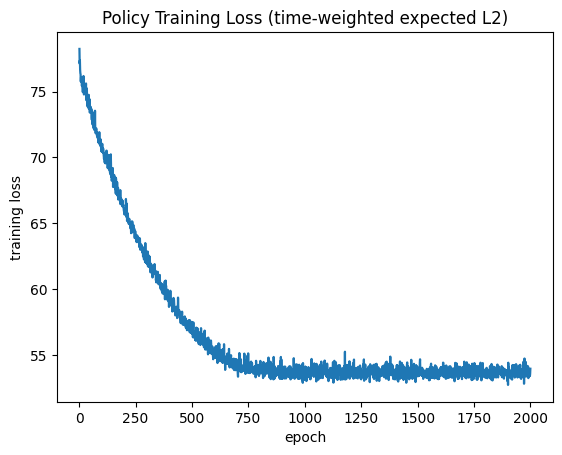

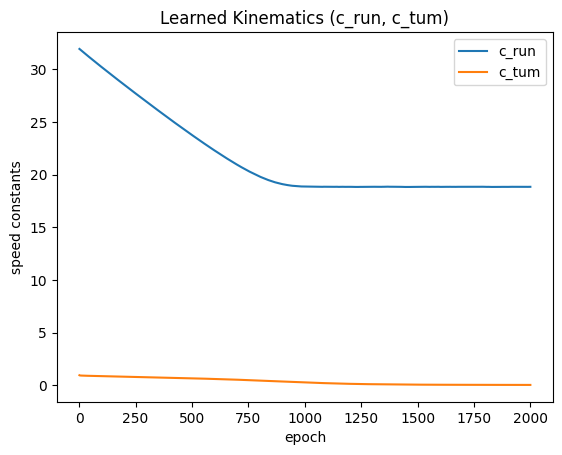

In [35]:
# plot
import matplotlib.pyplot as plt
epochs = [h["epoch"] for h in hist]
losses = [h["loss"]  for h in hist]
c_run  = [h["c_run"] for h in hist]
c_tum  = [h["c_tum"] for h in hist]

plt.figure()
plt.plot(epochs, losses, linewidth=1.6)
plt.xlabel("epoch"); plt.ylabel("training loss")
plt.title("Policy Training Loss (time-weighted expected L2)")
plt.show()

plt.figure()
plt.plot(epochs, c_run, label="c_run")
plt.plot(epochs, c_tum, label="c_tum")
plt.xlabel("epoch"); plt.ylabel("speed constants")
plt.title("Learned Kinematics (c_run, c_tum)")
plt.legend(); plt.show()


In [36]:
def export_TT_ZZ(tz, m):
    T_run = tz.T_run().detach().cpu().numpy()   # (n,n)
    T_tum = tz.T_tum().detach().cpu().numpy()   # (n,n)
    Z_nm2 = tz.Z().detach().cpu().numpy()       # (n, m^2)
    n = T_run.shape[0]
    TT_learn = np.stack([T_run, T_tum], axis=0) # (2,n,n)
    ZZ_learn = Z_nm2.reshape(n, m, m).transpose(1,2,0)  # (m,m,n)
    return TT_learn, ZZ_learn



TT_learn, ZZ_learn = export_TT_ZZ(tz, m)
TT_learn,ZZ_learn=torch.tensor(TT_learn),torch.tensor(ZZ_learn)
# print("TT_learn:", TT_learn.shape, "ZZ_learn:", ZZ_learn.shape)  # (2,n,n), (m,m,n)

env_new = Env(geom=geom, src=src, sensor=sensor, TT=TT_learn, ZZ=ZZ_learn)  # 若 Env 期望 numpy，这样最稳


## IRL reward learning

We optimize the reward from observation-conditioned expert action frequencies.
In this notebook, the curiosity term is set to zero.

In [37]:

def mutual_information(b: torch.Tensor, ZZ: torch.Tensor) -> torch.Tensor:
    """
    b: (n,) torch tensor (belief / prior)
    ZZ: either (m,m,n) or (m*m,n) emission matrix (columns sum to 1)
    returns: scalar torch tensor
    """
    # Match dtype/device to ZZ
    b = b.to(dtype=ZZ.dtype, device=ZZ.device)

    # Flatten to (m*m, n)
    if ZZ.dim() == 3:
        m1, m2, n = ZZ.shape
        Z = ZZ.reshape(m1*m2, n)
    else:
        Z = ZZ
        n = Z.shape[1]

    # Column-normalize (safety)
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)

    # Marginal: o = Z b
    o = Z @ b  # (m*m,)


    # term = sum_h b_h sum_v Z[v,h] log Z[v,h] - sum_v o_v log o_v
    logZ = torch.log(torch.clamp(Z, min=1e-12))
    col_term = (Z * logZ).sum(dim=0)        # (n,)
    term2 = (b * col_term).sum() - (o * torch.log(torch.clamp(o, min=1e-12))).sum()
    return term2

In [38]:
import torch, numpy as np

# ---------- Utility: posterior b(o) from observation index ----------
def build_B_from_observations(samples, ZZ_torch, m, device=None, dtype=torch.float32):
    """
    ZZ_torch: (m*m, n) column-normalized; samples contain 'o_idx'
    Returns B: (T, n). Each row is b(o_t) ∝ Z[o_t, :].
    """
    T = len(samples)
    idx = torch.tensor([s["o_idx"] for s in samples], dtype=torch.long, device=device)
    Z_o = ZZ_torch.index_select(0, idx)               # (T, n)
    B = Z_o / (Z_o.sum(dim=1, keepdim=True).clamp_min(1e-12))
    return B

# ---------- Batch mutual information I(B; Z) (optional curiosity) ----------
def batched_mutual_information(B, ZZ):
    """
    B:  (T, n) posterior beliefs
    ZZ: (m*m, n) emission matrix (columns sum to 1)
    Returns: I(B; Z) with shape (T,)
    """
    Z = ZZ
    logZ = torch.log(Z.clamp_min(1e-12))
    col_term = (Z * logZ).sum(dim=0)                 # (n,)
    t1 = (B * col_term.unsqueeze(0)).sum(dim=1)      # (T,)
    O = (Z @ B.T).T                                  # (T, m*m)
    t2 = (O * torch.log(O.clamp_min(1e-12))).sum(dim=1)
    return t1 - t2                                   # (T,)

# ---------- Key change: expert probabilities come from data, not from the learned policy ----------
def collect_expert_probs_from_data(samples, m, device=None, dtype=torch.float32,
                                   mode="bin", alpha=1.0):
    """
    Return P_exp: (T,2) = [p_run, p_tum] as the 'expert' distribution.
    Two modes:
      - mode='sample': per-sample one-hot (requires samples[i]['a'] ∈ {0,1})
      - mode='bin'   : aggregate counts by observation o_idx + Laplace smoothing to get π,
                      then assign back to each sample
    alpha: Laplace smoothing strength (bin mode)
    """
    T = len(samples)
    idx = torch.tensor([s["o_idx"] for s in samples], dtype=torch.long, device=device)
    if mode == "sample":
        if "a" not in samples[0]:
            raise ValueError("mode='sample' requires samples to contain the binary label 'a'")
        a = torch.tensor([float(s["a"]) for s in samples], dtype=dtype, device=device)
        p_tum = torch.clamp(a, 1e-6, 1-1e-6)
        P_exp = torch.stack([1.0 - p_tum, p_tum], dim=1)
        return P_exp

    # mode == 'bin': for each observation o_idx, count run/tumble frequencies and smooth
    mm = m*m
    # If action labels a are missing, align action_id from the original df to the window; otherwise require samples['a']
    if "a" in samples[0]:
        a_np = np.array([float(s["a"]) for s in samples], float)
        a = torch.tensor(a_np, dtype=dtype, device=device)
        counts = torch.zeros(mm, 2, dtype=dtype, device=device)  # [:,0]=run, [:,1]=tumble
        # Accumulated counts
        for k in range(T):
            oi = int(idx[k])
            ak = int(a[k].item() >= 0.5)
            counts[oi, ak] += 1.0
    else:
        raise ValueError("To aggregate experts with mode='bin', samples must contain 'a' or you must construct per-bin counts yourself.")

    # Laplace smoothing
    denom = counts.sum(dim=1, keepdim=True) + 2*alpha
    p_tum_o = (counts[:, 1] + alpha) / denom.squeeze(1)          # (mm,)
    p_tum = p_tum_o.index_select(0, idx)                         # (T,)
    p_tum = torch.clamp(p_tum, 1e-6, 1-1e-6)
    P_exp = torch.stack([1.0 - p_tum, p_tum], dim=1)             # (T,2)
    return P_exp

# ---------- IRL: learn r from the 'data expert' ----------
def train_irl_reward_from_obs_data(samples, env,
                                   r0, m, tau=1.0, curiosity=0.0,
                                   lr=5e-2, epochs=200, lambda_r=1e-3,
                                   expert_mode="bin", alpha=1.0,    # How the expert probabilities are constructed
                                   time_weight=False,               # Whether to use dt as sample weights
                                   device=None):
    """
    Similar to your original train_irl_reward_from_obs, but the expert distribution P_exp comes from data,
    not from the policy.
    - expert_mode='sample': per-sample one-hot
    - expert_mode='bin': smoothed by observation bins (recommended, robust)
    """
    # ----- ZZ -> (m*m, n)
    if isinstance(env.ZZ, np.ndarray):
        ZZ = torch.tensor(env.ZZ, dtype=torch.float32, device=device)
    else:
        ZZ = env.ZZ.to(device=device, dtype=torch.float32)
    if ZZ.dim() == 3:
        mm, mm2, n_states = ZZ.shape
        ZZ = ZZ.reshape(mm*mm2, n_states)
    else:
        n_states = ZZ.shape[1]
    ZZ = ZZ / ZZ.sum(dim=0, keepdim=True).clamp_min(1e-12)   # Column-normalize (safety)

    # ----- TT -> (A, n, n)
    if isinstance(env.TT, np.ndarray):
        TT = torch.tensor(env.TT, dtype=torch.float32, device=device)
    else:
        TT = env.TT.to(device=device, dtype=torch.float32)
    A = TT.shape[0]
    n = TT.shape[1]

    # ----- Reward parameters r
    r = torch.nn.Parameter(torch.tensor(r0, dtype=torch.float32, device=device))
    opt = torch.optim.Adam([r], lr=lr)

    # ----- Construct b(o_t) and the 'data-expert' distribution P_exp
    B = build_B_from_observations(samples, ZZ, m, device=device)  # (T, n)
    P_exp = collect_expert_probs_from_data(samples, m, device=device,
                                           dtype=torch.float32, mode=expert_mode, alpha=alpha)  # (T,2)

    # Optional: time weighting
    if time_weight:
        W = torch.tensor([float(s["dt"]) for s in samples], dtype=torch.float32, device=device)
        W = W / W.sum()
    else:
        W = None

    hist=[]
    for ep in range(1, epochs+1):
        opt.zero_grad()

        # ---- Compute Q_r(o,a) in batch
        Qs = []
        for a_idx in range(A):
            Tb = (TT[a_idx] @ B.T).T                       # (T,n)
            term1 = (r * Tb).sum(dim=1)                    # (T,)
            if curiosity > 0.0:
                mi = batched_mutual_information(Tb, ZZ)    # (T,)
                Qa = term1 + curiosity * mi
            else:
                Qa = term1
            Qs.append(Qa)
        Q = torch.stack(Qs, dim=1)                         # (T,A)

        # Soft policy (determined by r)
        P_r = torch.softmax(Q / float(tau), dim=1)         # (T, A)

        # ---- Cross-entropy (maximum likelihood) + L2 regularization
        ce = - (P_exp * torch.log(P_r.clamp_min(1e-12))).sum(dim=1)  # (T,)
        if W is not None:
            loss = (W * ce).sum() + lambda_r * (r*r).sum()
        else:
            loss = ce.mean() + lambda_r * (r*r).sum()

        loss.backward()
        opt.step()

        rec = dict(epoch=ep, loss=float(loss.item()))
        hist.append(rec)
        if ep==1 or ep%50==0:
            print(f"[IRL-obs DATA ep {ep:03d}] J={rec['loss']:.4e}")

    return r.detach().cpu().numpy(), hist


In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initial value of r
r0 = np.zeros(n, dtype=np.float32)
r0[0] = 10.0
r0[1] = r0[-1] = 8.0

# Expert distribution via 'observation bins + Laplace smoothing' (robust), optionally dt-weighted
r_star, irl_hist = train_irl_reward_from_obs_data(
    train_samples, env=env_new,
    r0=r0, m=m, tau=1.0, curiosity=0.0,
    lr=5e-2, epochs=1000, lambda_r=1e-3,
    expert_mode="bin", alpha=1.0,
    time_weight=False,            # If sample dt is non-uniform but want time-weighting, set True
    device=device
)
print("Learned reward r:", r_star)


[IRL-obs DATA ep 001] J=1.0108e+00
[IRL-obs DATA ep 050] J=8.4044e-01
[IRL-obs DATA ep 100] J=7.6261e-01
[IRL-obs DATA ep 150] J=7.2314e-01
[IRL-obs DATA ep 200] J=7.0433e-01
[IRL-obs DATA ep 250] J=6.9655e-01
[IRL-obs DATA ep 300] J=6.9379e-01
[IRL-obs DATA ep 350] J=6.9296e-01
[IRL-obs DATA ep 400] J=6.9274e-01
[IRL-obs DATA ep 450] J=6.9270e-01
[IRL-obs DATA ep 500] J=6.9269e-01
[IRL-obs DATA ep 550] J=6.9269e-01
[IRL-obs DATA ep 600] J=6.9269e-01
[IRL-obs DATA ep 650] J=6.9269e-01
[IRL-obs DATA ep 700] J=6.9269e-01
[IRL-obs DATA ep 750] J=6.9269e-01
[IRL-obs DATA ep 800] J=6.9269e-01
[IRL-obs DATA ep 850] J=6.9269e-01
[IRL-obs DATA ep 900] J=6.9269e-01
[IRL-obs DATA ep 950] J=6.9269e-01
[IRL-obs DATA ep 1000] J=6.9269e-01
Learned reward r: [ 0.04934065 -0.19736202  0.04934075  0.04934444  0.04934084]


## save checkpoints

In [40]:
import pickle

checkpoint = {
    "TT_learn": TT_learn.detach().cpu().numpy() if hasattr(TT_learn, "detach") else np.asarray(TT_learn),
    "ZZ_learn": ZZ_learn.detach().cpu().numpy() if hasattr(ZZ_learn, "detach") else np.asarray(ZZ_learn),
    "r_star": np.asarray(r_star),
    "kin_sim": {
        "c_run": float(kin()[0]),
        "c_tum": float(kin()[1]),
    },
    "geom": geom,
    "src": src,
    "sensor": sensor,
    "light_xy": np.asarray(light_xy).tolist(),
    "n": int(n),
    "m": int(m),
    "dt_policy": float(dt_policy),
    "stats": stats,
    "train_cells": list(map(int, train_cells)),
    "test_cells": list(map(int, test_cells)),
    "meta": {
        "source_processed": "data/processed/clean_movie_52_with_speed_and_action.csv",
        "created_by": "notebooks/02_Data_Driven_IRL.ipynb",
        "description": "Minimal checkpoint for 03_Benchmarking_and_Plots"
    }
}

ckpt_path = CKPT_DIR / "experiment_checkpoint.pkl"
with open(ckpt_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Saved checkpoint to:", ckpt_path)
print("Checkpoint keys:", list(checkpoint.keys()))

Saved checkpoint to: /content/phototaxis-pomdp-crn/checkpoints/experiment_checkpoint.pkl
Checkpoint keys: ['TT_learn', 'ZZ_learn', 'r_star', 'kin_sim', 'geom', 'src', 'sensor', 'light_xy', 'n', 'm', 'dt_policy', 'stats', 'train_cells', 'test_cells', 'meta']


/tmp/ipykernel_26619/1334544066.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  "c_run": float(kin()[0]),
